# Optimal Control — AFM State (Pascal)

## Kernel & Virtual Environment

This notebook uses a dedicated virtual environment to avoid breaking the main Qiskit setup (numpy 2.x incompatibility with scikit-optimize).

### Why a separate venv?
- `scikit-optimize` (`skopt`) requires an older numpy ABI
- The main `Python 3.11.9` kernel uses numpy 2.4.6 (required by Qiskit 2.4.1)
- Installing `skopt` there caused a `ValueError: numpy.dtype size changed` binary incompatibility

### Where the venv lives
```
C:\Users\patri\venvs\pascal-optimal-control\
```
It is **not** inside the project folder (Google Drive mount) — venvs do not work reliably on network-mounted drives.

Created with `--system-site-packages` so it inherits all system packages (Qiskit, numpy, scipy, etc.) and only adds `scikit-optimize` on top.

### How to select in VS Code
1. Click the kernel name (top-right of the notebook)
2. **"Select Another Kernel..."**
3. **"Jupyter Kernel..."** (not "Python Environments")
4. Select **"Python 3.11 (Pascal)"**

### Recreate from scratch (if needed)
```powershell
python -m venv "C:\Users\patri\venvs\pascal-optimal-control" --system-site-packages
& "C:\Users\patri\venvs\pascal-optimal-control\Scripts\Activate.ps1"
pip install scikit-optimize ipykernel
python -m ipykernel install --user --name pascal-venv --display-name "Python 3.11 (Pascal)"
```

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import qutip
from skopt import gp_minimize

from pulser import Pulse, Sequence, Register
from pulser_simulation import QutipBackendV2
from pulser.waveforms import InterpolatedWaveform
from pulser.devices import AnalogDevice

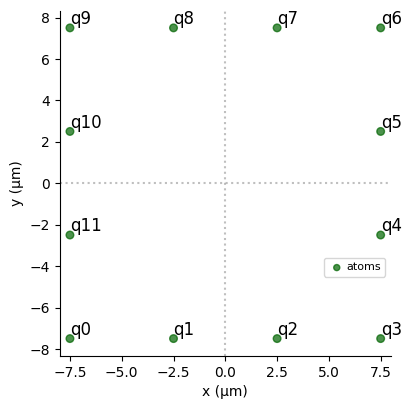

In [2]:
device = AnalogDevice

R_interatomic = 5 # µm

N_side = 4
coords = (
    [R_interatomic * np.r_[x, 0] for x in range(N_side - 1)]
    + [R_interatomic * np.r_[N_side - 1, y] for y in range(N_side - 1)]
    + [
        R_interatomic * np.r_[N_side - 1 - x, N_side - 1]
        for x in range(N_side - 1)
    ]
    + [R_interatomic * np.r_[0, N_side - 1 - y] for y in range(N_side - 1)]
)
reg = Register.from_coordinates(coords, prefix="q")
N = len(coords)
reg.draw()

In [3]:
seq = Sequence(reg, device)

In [4]:
seq.declare_channel("ising", "rydberg_global")

In [5]:
# The target is to optimize Omeaga and omega ramp curves to obtain a better solution
# This is done my interpolating their curve using m parameters.
# m is obtipized by an algorithm.

T = 1000 # in µs

m = 3

tol = 1e-6 # This is set to protect the code against python aproximation + machine tolerance

max_amp = seq.declared_channels["ising"].max_amp * (1 - tol)
Omega_max = min(max_amp, device.rabi_from_blockade(1.2 * R_interatomic)) # This ensure that atoms at R_interatomic from
                                                                         # each other are impacted by the blockade

U = 2 * Omega_max
max_det = seq.declared_channels["ising"].max_abs_detuning * (1 - tol)
delta_0 = -min(max_det, U)
delta_f = min(max_det, U)

amp_params = np.random.uniform(0, Omega_max, m)
det_params = np.random.uniform(delta_0, delta_f, m)

In [6]:
# Start/End values
# Omega(0) = Omega(T) = 0
# delta(0) = delta_0 et delta(T) = delta_f

def create_interp_pulse(amp_params, det_params):
    return Pulse(
        InterpolatedWaveform(T, [1e-9, *amp_params, 1e-9]),
        InterpolatedWaveform(T, [delta_0, *det_params, delta_f]),
        0
    )

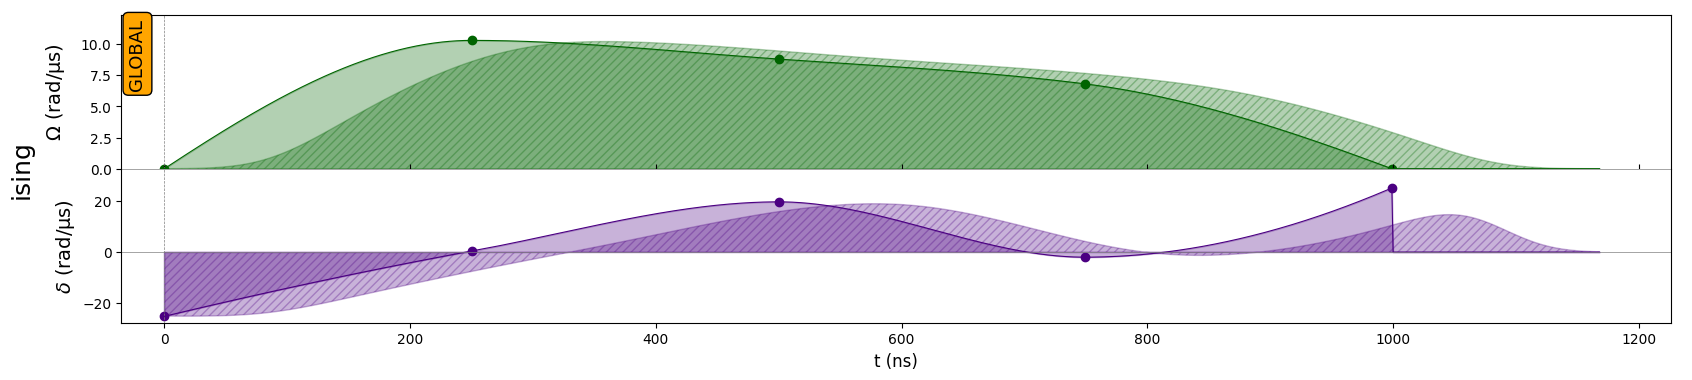

In [7]:
seq.add(create_interp_pulse(amp_params, det_params), "ising")
seq.draw()

Counter({'000000000000': 72, '100000100000': 38, '000100000100': 29, '010001000000': 23, '100010000000': 23, '010000010000': 22, '000001000100': 20, '000000100010': 18, '010000100000': 18, '001000001000': 18, '000010000010': 16, '001000000100': 16, '000100000001': 15, '001000000010': 15, '000000100001': 15, '000001000001': 14, '001000100000': 14, '000000100000': 14, '000010000000': 13, '010000000100': 13, '100000010000': 12, '100000000000': 12, '000000010001': 12, '100001000000': 11, '000010000100': 11, '000000000010': 11, '000010001000': 11, '000100001000': 11, '001010001000': 11, '010001000001': 11, '000100000010': 10, '000010000001': 10, '000000000100': 10, '000100010000': 10, '010000010001': 9, '000100000000': 9, '010000001000': 9, '100000001000': 9, '001000000000': 9, '001010100000': 8, '000001000000': 7, '000001000010': 7, '000000010000': 7, '000000000001': 7, '000010001010': 7, '001010000010': 7, '010000000000': 7, '010001010000': 7, '000001010001': 6, '001000001010': 6, '100000

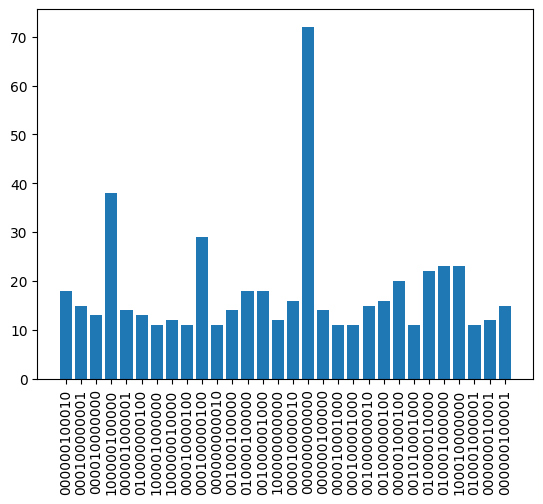

In [8]:
N_samples = 1000

simul = QutipBackendV2(seq)
results = simul.run()

final_state = results.final_state
counts = final_state.sample(num_shots=N_samples)
print(counts)

most_freq = {k: v for k, v in counts.items() if v > 10}
plt.bar(list(most_freq.keys()), list(most_freq.values()))
plt.xticks(rotation="vertical")
plt.show()

In [11]:
def occupation(j, N):
    up = qutip.basis(2, 0, dtype="CSR")
    prod = [qutip.qeye(2, dtype="CSR") for _ in range(N)]
    prod[j] = up * up.dag()
    return qutip.tensor(prod)

def get_corr_pairs(k, N):
    corr_pairs = [[i, (i + k) % N] for i in range(N)]
    return corr_pairs

def get_corr_function(k, N, state):
    corr_pairs = get_corr_pairs(k, N)
    operators = [occupation(j, N) for j in range(N)]
    covariance = 0
    for qi, qj in corr_pairs:
        covariance += qutip.expect(operators[qi] * operators[qj], state)
        covariance -= qutip.expect(operators[qi], state) * qutip.expect(operators[qj], state)
    return covariance / len(corr_pairs)

def get_neel_structure_factor(reg, state):
    N = len(reg.qubits)
    st_fac = 0
    for k in range(-N // 2, N // 2 + 1):
        kk = np.abs(k)
        st_fac += 4 * (-1) ** kk * get_corr_function(k, N, state)
    return st_fac

In [12]:
# The Neel SF should reach 1 for a perfect AFM state - let's verify

AFM1 = qutip.tensor([qutip.basis(2, k % 2) for k in range(N)])
AFM2 = qutip.tensor([qutip.basis(2, (k + 1) % 2) for k in range(N)])
AFM_state = (AFM1 + AFM2).unit()

t1 = time.process_time()
S_max = get_neel_structure_factor(reg, AFM_state)
print("S_Neel(AFM State) = ", S_max)
t2 = time.process_time()
print("computed in", (t2 - t1), "sec")

S_Neel(AFM State) =  13.0
computed in 0.078125 sec


In [ ]:
print(N)
print(AFM_state.dims)
print(AFM_state.norm())

12
[[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], [1]]
1.4142135623730951


In [13]:
def score(params):
    """ Computes the score associated with a set of parameters. """
    seq = Sequence(reg, AnalogDevice)
    seq.declare_channel("ising", "rydberg_global")
    seq.add(create_interp_pulse(params[:m], params[m:]), "ising")

    simul = QutipBackendV2(seq)
    results = simul.run()

    sampling = results.final_state.sample(num_shots=N_samples)
    sampled_state = sum(
        [
            np.sqrt(sampling[k] / N_samples) * qutip.ket(k, dtype="CSR")
            for k in sampling.keys()
        ]
    )

    F = get_neel_structure_factor(reg, sampled_state) / S_max

    return 1 - F

In [14]:
score(np.r_[amp_params, det_params])

np.float64(0.8944700000000001)

In [19]:
# Optimization de 2m parametrès pour Omega et delta
# On utilise gp_minimize : ici, n_r ce sont les points du tirage initial où est évaluée la boîte noire F
# n_c ce sont les points supplémentaires sur lesquels on va evaluer F au cours de l'algorithme

# NOTE SUR LA RECHERCHE DU PROCHAIN POINT (FONCTION D'ACQUISITION alpha) :
# Pour trouver le meilleur candidat pour l'évaluation de F à chaque itération, gp_minimize doit maximiser la fonction d'acquisition alpha. 
# Ces milliers d'évaluations intermédiaires sont gérées de manière en interne :
# - En basse dimension : scikit-optimize échantillonne une grille virtuelle dense de l'espace.
# - En haute dimension : l'algorithme bascule automatiquement sur une optimisation de la fonction alpha 
#   via des descentes de gradient avec départs multiples (Multi-Start L-BFGS-B) pour trouver le minimum absolu.

bounds = [(0.0, Omega_max)] * m + [(delta_0, delta_f)] * m

n_r = 30
n_c = 200

RESULT = gp_minimize(
    score, bounds, n_random_starts=n_r, n_calls=n_c, verbose=False
)


In [20]:
def sort_improv(RESULT):
    score_vals = RESULT.func_vals
    min = score_vals[0]
    score_list = []
    for s in score_vals:
        if s < min:
            min = s
            score_list.append(min)
        else:
            score_list.append(min)
    return score_list

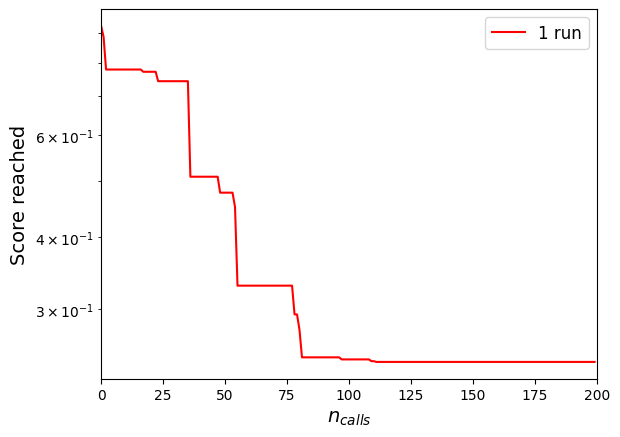

In [21]:
fig = plt.figure()
plt.semilogy(range(n_c), sort_improv(RESULT), "r-")
plt.xlabel(r"$n_{calls}$", fontsize = 14)
plt.ylabel("Score reached", fontsize = 14)
plt.legend(["1 run"], fontsize=12)
plt.xlim(0, n_c)
plt.show()

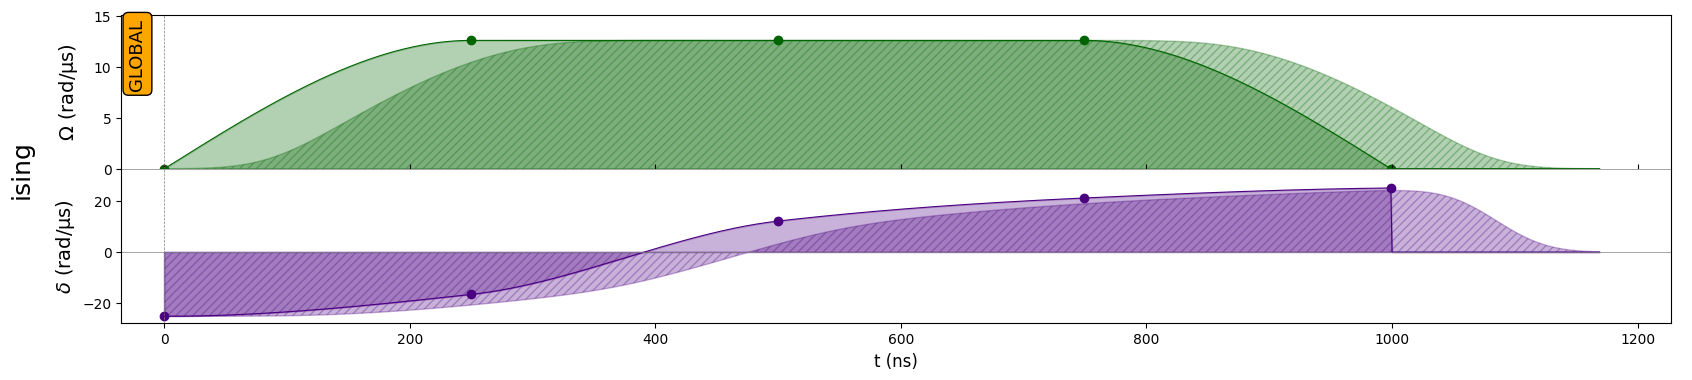

In [22]:
# Now, I can use those m parameters to optimize the pulse ramp function
seq = Sequence(reg, AnalogDevice)
seq.declare_channel("ising", "rydberg_global")
P = create_interp_pulse(RESULT.x[:m], RESULT.x[m:])
seq.add(P, "ising")
seq.draw()

Most frequent bitstrings measured (1000 measurements) {'101010101010': 275, '001001010101': 12, '010101010101': 307, '101010100100': 16, '001010101001': 16, '010101010100': 13, '101010001010': 14, '010100100101': 20, '010101001001': 19, '010010010101': 14, '100100101010': 17, '000101010101': 11, '010010101010': 16, '100101010100': 14, '101001001010': 18, '010101000101': 11, '101010010010': 16, '100010101010': 14}
S_Neel (final_sampled) = 9.299


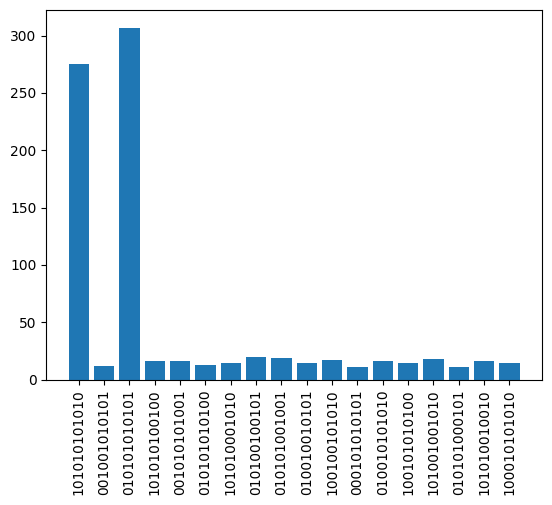

In [23]:
simul = QutipBackendV2(seq)
results = simul.run()
sampling = results.final_state.sample(num_shots=N_samples)
sampled_state = sum(
    [np.sqrt(sampling[k] / 1000) * qutip.ket(k) for k in sampling.keys()]
)

s_neel_sampled = np.round(get_neel_structure_factor(reg, sampled_state), 3)
most_freq = {k: v for k, v in sampling.items() if v > 10}

print(
    f"Most frequent bitstrings measured ({N_samples} measurements)", most_freq
)
print(f"S_Neel (final_sampled) = {s_neel_sampled}")
plt.bar(list(most_freq.keys()), list(most_freq.values()))
plt.xticks(rotation="vertical")
plt.show()